# Libraries and loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import time
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');
import MAS_library as MASL
import plotting_library as PL
from pylab import *
from matplotlib.colors import LogNorm
import matplotlib as plt
import pandas as pd
import h5py as h5
import matplotlib.pyplot as plt
from colossus.cosmology import cosmology
from colossus.lss import mass_function
import mass_function_library as MFL

ModuleNotFoundError: No module named 'colossus'

# Loading Halo Catalogues

In [3]:
sim_spec_s= "L_1024_Ngrid_512/"
sim_spec_m= "L_1024_Ngrid_1024/"
simul="0.0ev"
sim_l="nu0meV"

halos_catalogue_small = np.loadtxt("./../../simulations/"+sim_spec_s+sim+"/output/halos/subhalo_out_2.list");
halos_catalogue_medium =np.loadtxt("./../../simulations/"+sim_spec_m+"/simulations/"+sim+"/output/halos/subhalo_out_2.list");
halos_catalogue_large = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat");


# HMF from Pylians and Clossus

In [4]:
import mass_function_library as MFL
##### Clossus
# M = 10**np.arange(11.0, 15.5, 0.1)
# mfunc = mass_function.massFunction(M, z[i], mdef = '200m', model = 'tinker08', q_out = 'dndlnM')

## Pylians
def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
HMF = nested_dict(4, list)

M_min = 12.2
M_max = 16.1
num = 100

names = ['ST','Tinker','Tinker10']

class_lcdm =  np.loadtxt("./../class_runs/lcdm/output/file_z18_pk.dat")
Pk_lcdm = class_lcdm[:,1] #file with linear Pk
k_lcdm =  class_lcdm[:,0]
##
class_0d3 =  np.loadtxt("./../class_runs/0d3eV//output/file_z18_pk.dat")
Pk_0d3 = class_0d3[:,1] #file with linear Pk
k_0d3 =  class_0d3[:,0]

OmegaM = 0.3189
Masses = np.logspace(M_min, M_max, num) #array with halo masses
bins   = 10000  #number of bins to use for Pk
z      = 0.0    #redshift; only used for Tinker, Tinker10 and Crocce
delta  = 200.0  #overdensity; only for Tinker and Tinker10
# read linear matter Pk
# compute halo mass function
for author in names:
    HMF_data = MFL.MF_theory(k_lcdm, Pk_lcdm, OmegaM, Masses, author, bins, z, delta)
    HMF[author]['dNdlogM']['lcdm'] = HMF_data;
    
    HMF_data_0d3 = MFL.MF_theory(k_0d3, Pk_0d3, OmegaM, Masses, author, bins, z, delta)
    HMF[author]['dNdlogM']['nu0d3'] = HMF_data_0d3;

Delta= 200.0
A= 0.186
a= 1.47
b= 2.57
c= 1.19
Delta= 200.0
A= 0.186
a= 1.47
b= 2.57
c= 1.19


## Print the headers and each column

In [54]:
def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
data = nested_dict(6, list)

f = open("./../../simulations/"+sim_spec_s+simul+"/output/halos/subhalo_out_2.list")
g = open("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat")

header = f.readline()
header_l = g.readline()

header_list = header.split(' ') #list of columns
header_list_l = header_l.split(' ') #list of columns

print(header_list)
print(header_list_l)
print(header_list.index("Mvir"))
for num in [0, 1, 2, 20, 41]:
    print("Column: "+str(num)+ " is " + header_list[num])


['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius', 'PID\n']
['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius', 'PID\n']
2
Column: 0 is #ID
Column: 1 is DescID
Column: 2 is Mvir
Column: 20 is M200b
Column: 41 is PID



# Removing sub-halos vs Mass cuts

In [63]:
Mass_Vir_cuts = [1.e12, 4.e13, 7.e13 ,1.e14, 4.e14]
sims = ['small', 'medium', 'large']
data['halos']['small'] = halos_catalogue_small
data['halos']['medium'] = halos_catalogue_medium
data['halos']['large'] = halos_catalogue_large

for sim in sims:
    sub_halo_condition = (data['halos'][sim][:,41]==-1)
    data['halos_no_subhalos'][sim] = data['halos'][sim][sub_halo_condition]
    for Mass_cut in Mass_Vir_cuts:
        mass_conditions = (data['halos'][sim][:,20]>=Mass_cut)
        data['halos_mass'][sim][Mass_cut] = data['halos'][sim][mass_conditions]

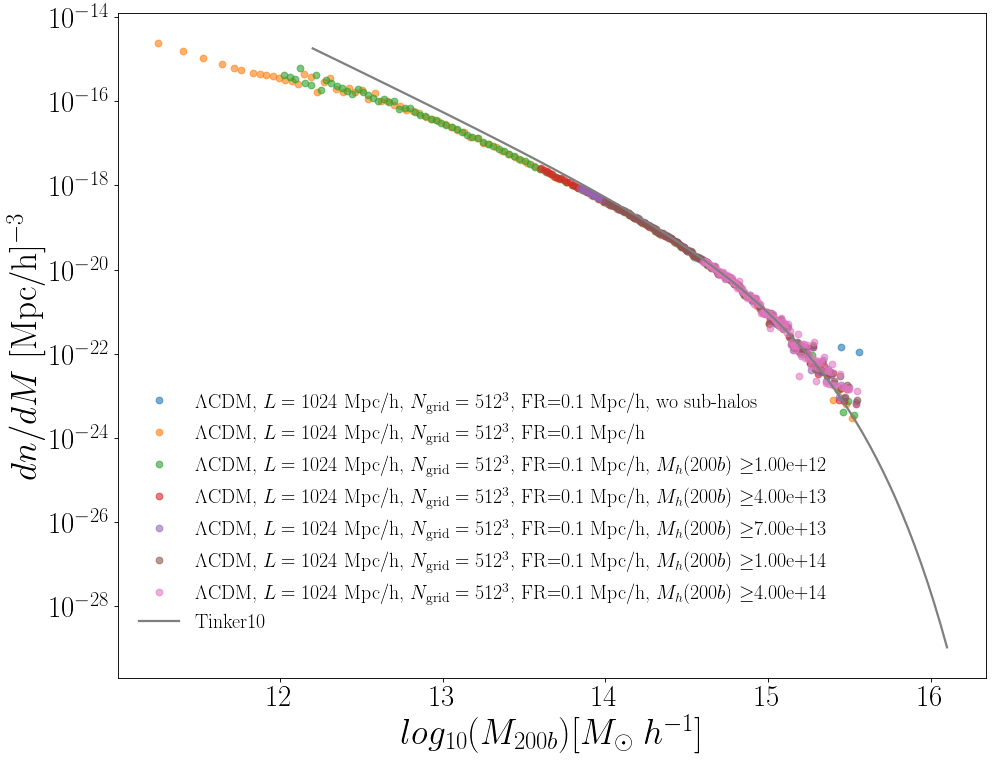

In [64]:
# f"{Mass_cut:.2e}"
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]


column = 20
alpha_num =0.6

for sim in ['medium']:
    ########
    nbins = 110;
    boxsize = 1024
    x=data['halos_no_subhalos'][sim][:,column];
    counts = np.histogram(np.log10(x), bins=nbins)[0]
    bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
    deltaM= bin_edges[2]- bin_edges[1];
    plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h, wo sub-halos")
    ########
    nbins = 110;
    boxsize = 1024
    x=data['halos'][sim][:,column];
    counts = np.histogram(np.log10(x), bins=nbins)[0]
    bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
    deltaM= bin_edges[2]- bin_edges[1];
    plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h")
    ######## 
    for Mass_cut in Mass_Vir_cuts:
        ########
        nbins = 110;
        boxsize = 1024
        x=data['halos_mass'][sim][Mass_cut][:,column];
        counts = np.histogram(np.log10(x), bins=nbins)[0]
        bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
        deltaM= bin_edges[2]- bin_edges[1];
        plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h"+", $M_h(200b) \ge $" + f"{Mass_cut:.2e}")

        
for author in ["Tinker10"]:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=18,bbox_to_anchor=[0.42,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Large simulation

number of all halos: 675710
number of all parent halos: 620005
Ratio: 0.917560787911974


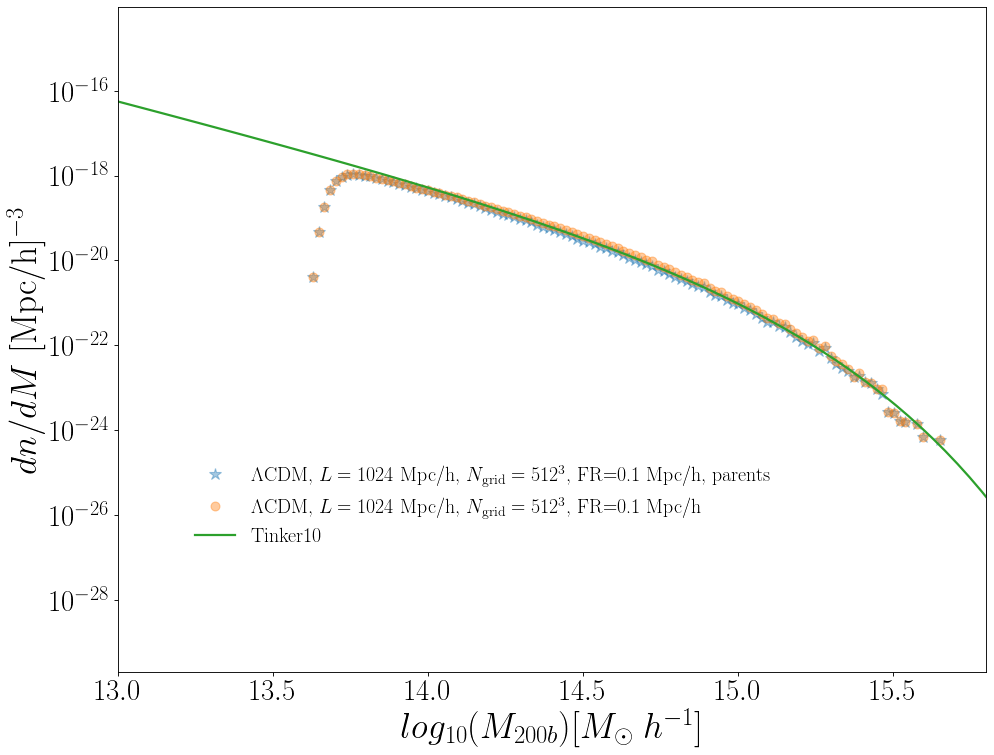

In [75]:
# f"{Mass_cut:.2e}"
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]


column = 20
alpha_num =0.4

for sim in ['large']:
    ########
    nbins = 110;
    boxsize = 2048
    x=data['halos_no_subhalos'][sim][:,column];
    counts = np.histogram(np.log10(x), bins=nbins)[0]
    bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
    deltaM= bin_edges[2]- bin_edges[1];
    print("number of all halos: "+str(np.shape(data['halos'][sim][:,column])[0]))
    print("number of all parent halos: "+str(np.shape(data['halos_no_subhalos'][sim])[0]))
    print("Ratio: "+str(np.shape(data['halos_no_subhalos'][sim])[0]/np.shape(data['halos'][sim][:,column])[0]) )
    plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"*", markersize=11, alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h, parents")
    ########
    nbins = 110;
    boxsize = 2048
    x=data['halos'][sim][:,column];
    counts = np.histogram(np.log10(x), bins=nbins)[0]
    bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
    deltaM= bin_edges[2]- bin_edges[1];
    plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", markersize=8, alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h")
    ######## 
    for Mass_cut in Mass_Vir_cuts:
        ########
        nbins = 110;
        boxsize = 2048
        x=data['halos_mass'][sim][Mass_cut][:,column];
        counts = np.histogram(np.log10(x), bins=nbins)[0]
        bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
        deltaM= bin_edges[2]- bin_edges[1];
        # plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", alpha = alpha_num, label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h"+", $M_h \ge $" + f"{Mass_cut:.2e}")

        
for author in ["Tinker10"]:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.xlim(13,15.8)
plt.legend(fontsize=18,bbox_to_anchor=[0.42,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Different force resolution medium sim

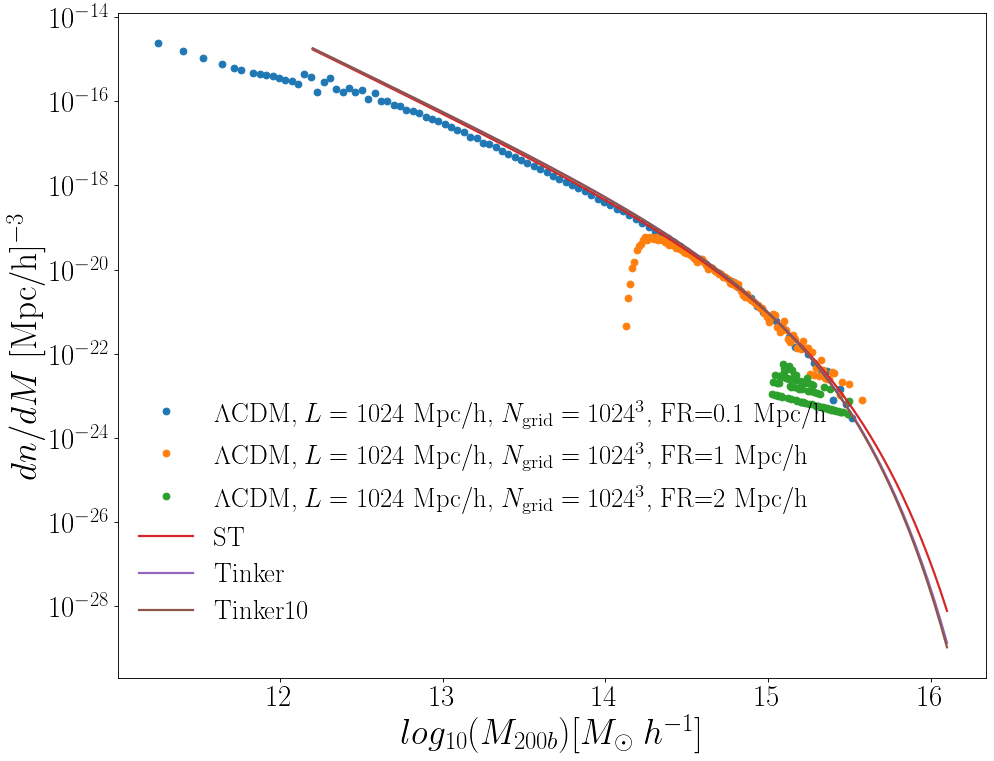

In [14]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=0.1 Mpc/h")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium_force1[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=1 Mpc/h")


nbins = 110;
boxsize = 2048
x=halos_catalogue_medium_force2[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=2 Mpc/h")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=24,bbox_to_anchor=[0.42,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Plotting halo mass function

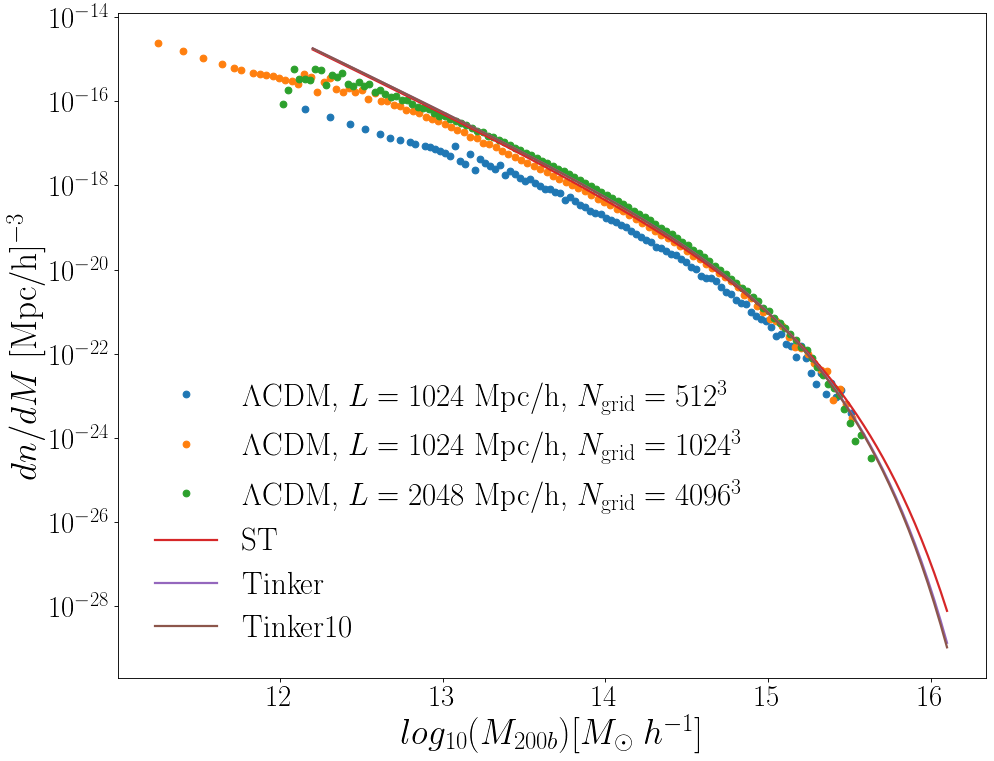

In [7]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# $M_{\rm vir}$

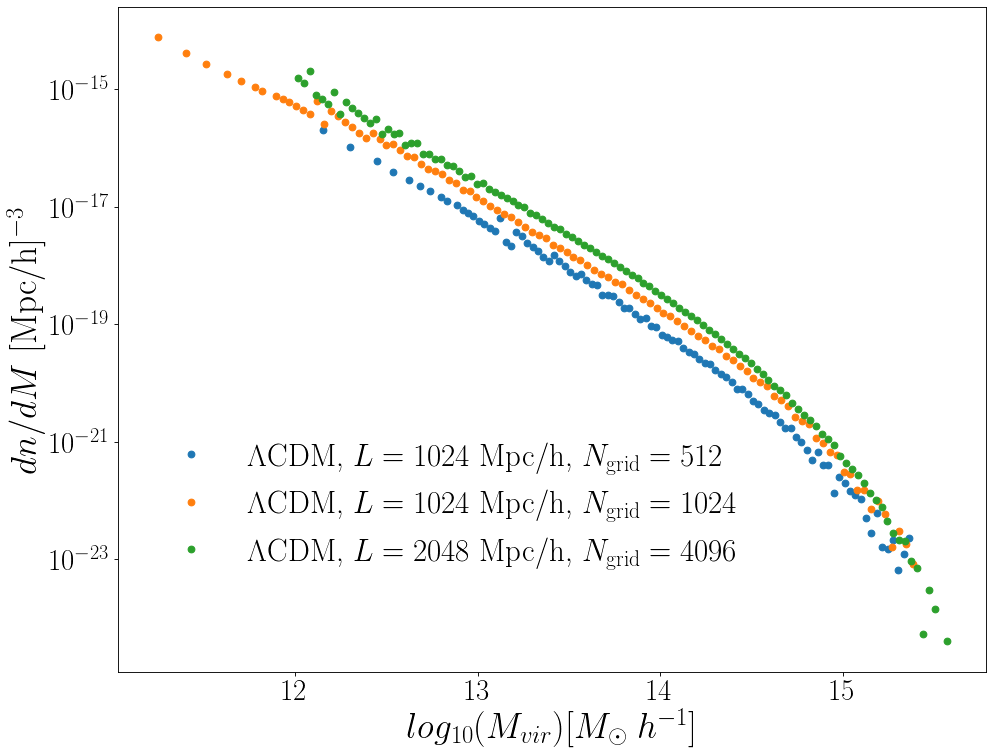

In [6]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{vir}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

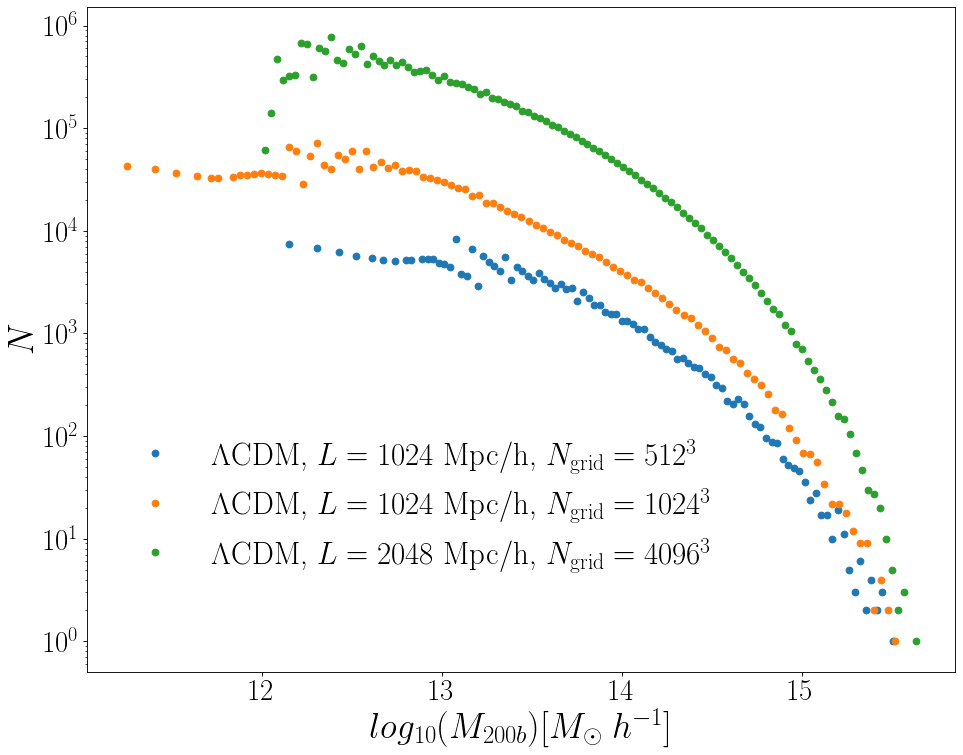

In [11]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

# for author in names:
#     plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$N$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

## 0.3 eV

In [54]:
# sim_spec_s= "L_1024_Ngrid_512/"
# sim_spec_m= "L_1024_Ngrid_1024/"
# sim="0.3ev"
# sim_l="nu300meV"

# halos_catalogue_small = np.loadtxt("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list");
# halos_catalogue_medium =np.loadtxt("./../../simulations/"+sim_spec_m+"/simulations/"+sim+"/output/halos/out_2.list");
# halos_catalogue_large = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat");


In [8]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]

# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_small[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_medium[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


# nbins = 110;
# boxsize = 2048
# x=halos_catalogue_large[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



# plt.xlabel(r"$dx$ [Mpc/h]")
# plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
# plt.xlabel(r'$log_{10} M[ M_{\odot} \; h^{-1}$]',fontsize=32)
# plt.yscale('log')
# plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )